# Employee Attrition Prediction using Machine Learning

### Internship Project – Week 2

**Name:** Noor Afshan

**Dataset:** IBM HR Analytics Employee Attrition Dataset

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

**Objective:**
The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on factors such as salary, job satisfaction, work-life balance, experience, and other employee-related information.

# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Task 1: Data Loading and Exploration

## Loading the Dataset

In [2]:
df = pd.read_csv("HR_Attrition.csv")

## Displaying the First 10 Rows

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Observation

The dataset contains employee-related information such as age, department, salary, work-life balance, job satisfaction, years at the company, and many other factors. Each row represents one employee, while each column represents a specific feature. The target column is **Attrition**, which indicates whether an employee left the company (`Yes`) or stayed (`No`).

## Dataset Shape

In [4]:
df.shape

(1470, 35)

### Observation

The dataset contains **1470 employee records** and **35 columns**. Each row represents one employee, while each column contains employee-related information used for prediction.

## Column Names

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Observation

The dataset contains both numerical and categorical columns, including employee demographics, job-related information, salary details, and the target column **Attrition**.

## Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Observation

The dataset contains 1470 rows and 35 columns. The columns include both numerical and categorical data types. All columns have complete data with no missing values.

## Missing Value Check

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

No missing values were found in the dataset. Therefore, no missing value treatment is required before preprocessing.

## Target Variable (Attrition)

In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Observation

The target variable **Attrition** contains two classes: **No** and **Yes**. Out of 1470 employees, **1233 employees stayed** with the company, while **237 employees left**. This shows that most employees remained in the organization.


## Attrition Rate

In [9]:
attrition_rate = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Observation

Approximately **83.9%** of employees stayed with the company, while **16.1%** left. The employee attrition rate is relatively low.

## Numerical and Categorical Columns

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 26
Categorical Columns: 9


### Observation

The dataset contains **26 numerical columns** and **9 categorical columns**. Numerical columns include measurable values such as age, monthly income, and years at the company, while categorical columns include department, job role, business travel, marital status, and attrition.

## Class Distribution Analysis

### Observation

The dataset is **imbalanced** because **1233 employees stayed** while only **237 employees left** the company. Since one class has significantly more records than the other, techniques such as **class_weight='balanced'** can help the machine learning model learn both classes more effectively.

# Task 2: Data Cleaning and Preprocessing

## Removing Irrelevant Columns

In [12]:
df_clean = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
)

df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


### Observation

The columns EmployeeNumber, EmployeeCount, Over18, and StandardHours were removed because they are either unique identifiers or constant-value columns that do not contribute to predicting employee attrition.

## Dataset Shape After Removing Columns

In [13]:
df_clean.shape

(1470, 31)

### Observation

After removing four unnecessary columns, the dataset now contains 31 columns that are more relevant for machine learning.

## Converting Target Variable into Numeric Values

In [14]:
df_clean["Attrition"] = df_clean["Attrition"].replace({
    "Yes": 1,
    "No": 0
})

df_clean["Attrition"].value_counts()

C:\Users\Acer\AppData\Local\Temp\ipykernel_21384\3663864532.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["Attrition"] = df_clean["Attrition"].replace({


Attrition
0    1233
1     237
Name: count, dtype: int64

### Observation

The target variable Attrition was converted into numeric values, where Yes was replaced with 1 and No was replaced with 0. Machine learning algorithms require numerical target values for training.

## One-Hot Encoding of Categorical Features

In [15]:
cat_cols = df_clean.select_dtypes(include="object").columns

cat_cols

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

## Applying One-Hot Encoding

In [16]:
df_clean = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

df_clean.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


### Observation

One-Hot Encoding was applied to all remaining categorical columns. This converted text-based categorical variables into binary (0/1) numerical columns. The parameter `drop_first=True` was used to avoid the dummy variable trap and reduce redundancy in the dataset.

In [17]:
df_clean.shape

(1470, 45)

### Observation

After applying One-Hot Encoding, the dataset shape changed from **(1470, 31)** to **(1470, 45)**. The number of rows remained the same because no employee records were removed. However, the number of columns increased because each categorical feature was converted into multiple binary (0/1) columns.

In [18]:
df_clean.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


### Observation

After applying One-Hot Encoding, all categorical features were successfully converted into numerical binary columns. The newly created columns contain **True/False** values, which represent binary values (**True = 1**, **False = 0**). This makes the dataset suitable for machine learning algorithms.

## Splitting Features and Target Variable

In [19]:
X = df_clean.drop("Attrition", axis=1)

y = df_clean["Attrition"]

In [20]:
print(X.shape)

print(y.shape)

(1470, 44)
(1470,)


### Observation

The dataset was divided into features (`X`) and the target variable (`y`). The feature set contains **44 input variables**, while the target variable is **Attrition**, which the model will predict.

## Splitting the Dataset into Training and Testing Sets

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


### Observation

The dataset was split into **80% training data** and **20% testing data**. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.

## Feature Scaling using StandardScaler

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [24]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1176, 44)
(294, 44)


### Observation

Feature Scaling was performed using **StandardScaler**. The scaler was fitted only on the training dataset and then applied to both the training and testing datasets. This prevents data leakage and ensures that all features are on a similar scale.

# Task 3: Exploratory Data Analysis (EDA)

## Attrition Rate by Department

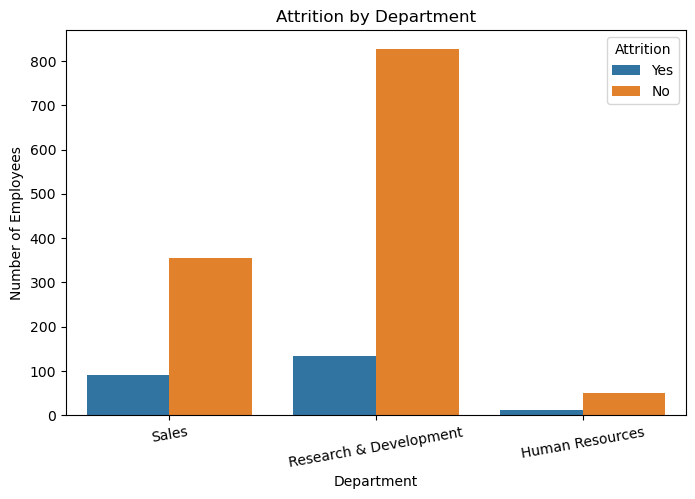

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=10)

plt.savefig("charts/chart1_department_attrition.png")

plt.show()

### Observation

The Research & Development department has the highest number of employees as well as the highest number of employees leaving the company. The Sales department also experiences a noticeable number of employee exits, while the Human Resources department has the lowest employee count and the fewest employees leaving the organization.

### Business Insight

Although Research & Development has the highest number of employees leaving, this may be influenced by its larger workforce. Therefore, attrition rate should also be analyzed to compare departments fairly. HR should closely monitor both the Research & Development and Sales departments to identify the reasons behind employee turnover.

### Department-wise Attrition Rate

The table below shows the percentage of employees who left the company in each department.

In [26]:
department_attrition_rate = (
    df.groupby("Department")["Attrition"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
      .reset_index()
)

department_attrition_rate = department_attrition_rate[
    department_attrition_rate["Attrition"] == "Yes"
]

department_attrition_rate["Rate"] = department_attrition_rate["Rate"].round(2)

department_attrition_rate

,Department,Attrition,Rate
1,Human Resources,Yes,19.05
3,Research & Development,Yes,13.84
5,Sales,Yes,20.63


In [27]:
department_attrition_rate.sort_values(
    by="Rate",
    ascending=False
)

,Department,Attrition,Rate
5,Sales,Yes,20.63
1,Human Resources,Yes,19.05
3,Research & Development,Yes,13.84


### Interpretation

The table above provides the attrition percentage for each department, making it easier to compare employee turnover regardless of department size.

## Attrition by Job Role

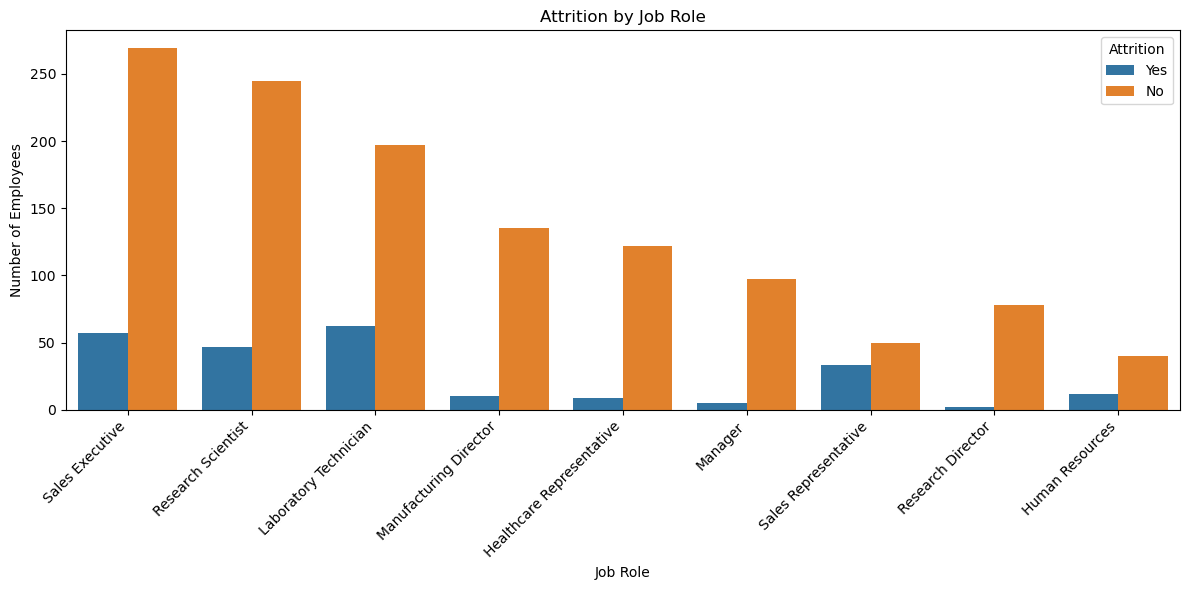

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig("charts/chart2_jobrole_attrition.png")

plt.show()

### Observation

Among all job roles, **Laboratory Technicians** show the highest number of employee exits. **Sales Executives** and **Research Scientists** also experience a considerable number of employees leaving the organization. On the other hand, **Research Directors** have the lowest number of employee exits, indicating better employee retention in that role.

### Business Insight

The HR team should pay special attention to Laboratory Technicians and Sales Executives by identifying the reasons behind employee turnover and implementing targeted retention strategies such as career development opportunities, better work-life balance, and employee engagement programs.

### Job Role-wise Attrition Rate

The table below shows the percentage of employees who left the company for each job role.

In [29]:
jobrole_attrition_rate = (
    df.groupby("JobRole")["Attrition"]
      .value_counts(normalize=True)
      .rename("Rate")
      .mul(100)
      .reset_index()
)

jobrole_attrition_rate = jobrole_attrition_rate[
    jobrole_attrition_rate["Attrition"] == "Yes"
]

jobrole_attrition_rate["Rate"] = jobrole_attrition_rate["Rate"].round(2)

jobrole_attrition_rate.sort_values(
    by="Rate",
    ascending=False
)

,JobRole,Attrition,Rate
17,Sales Representative,Yes,39.76
5,Laboratory Technician,Yes,23.94
3,Human Resources,Yes,23.08
15,Sales Executive,Yes,17.48
13,Research Scientist,Yes,16.10
9,Manufacturing Director,Yes,6.90
1,Healthcare Representative,Yes,6.87
7,Manager,Yes,4.90
11,Research Director,Yes,2.50


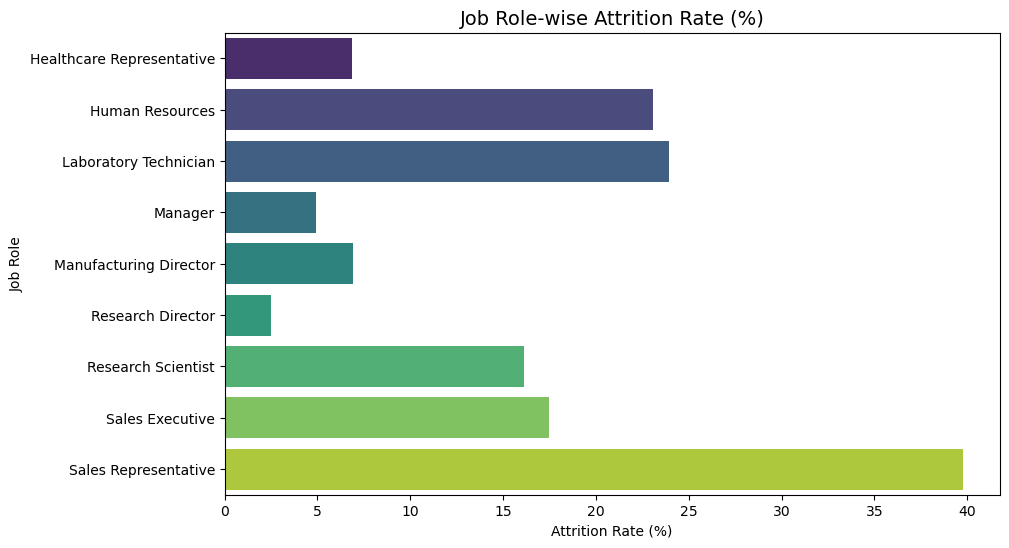

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=jobrole_attrition_rate,
    x="Rate",
    y="JobRole",
    hue="JobRole",
    palette="viridis",
    legend=False
)

plt.title("Job Role-wise Attrition Rate (%)", fontsize=14)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.savefig("charts/chart_jobrole_attrition_rate.png")

plt.show()

### Observation

The Sales Representative role has the highest attrition rate at **39.76%**, indicating that nearly 4 out of every 10 employees in this role leave the company. Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also have relatively high attrition rates. In contrast, Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates.

### Business Insight

The HR team should prioritize retention efforts for Sales Representatives, Laboratory Technicians, and Human Resources employees, as these roles experience the highest employee turnover. Understanding the reasons behind their resignations through surveys, feedback sessions, and career development programs could help reduce attrition. Employees in senior positions such as Managers and Research Directors appear to have greater job stability.

## Monthly Income vs Attrition

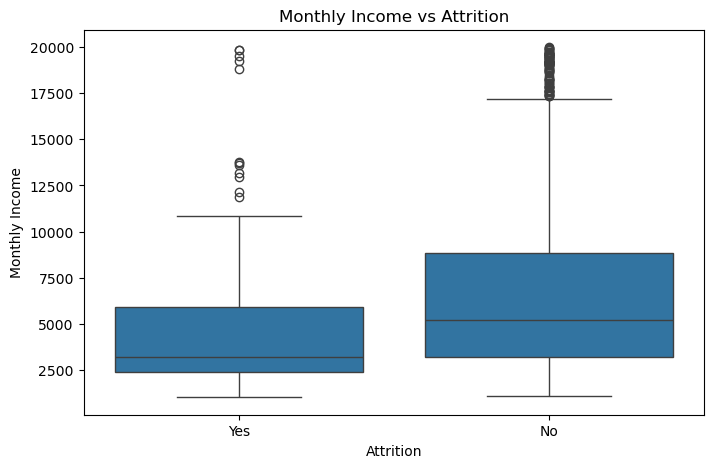

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.savefig("charts/chart3_income_attrition.png")

plt.show()

### Observation

Employees who left the company generally have a lower monthly income compared to employees who stayed. The median monthly income of employees who left is noticeably lower, although there are a few high-income employees who also resigned.

### Business Insight

Salary appears to influence employee attrition, but it is not the only factor. The HR team should pay special attention to lower-income employees while also considering other factors such as job satisfaction, career growth, and work-life balance.

## Work-Life Balance vs Attrition

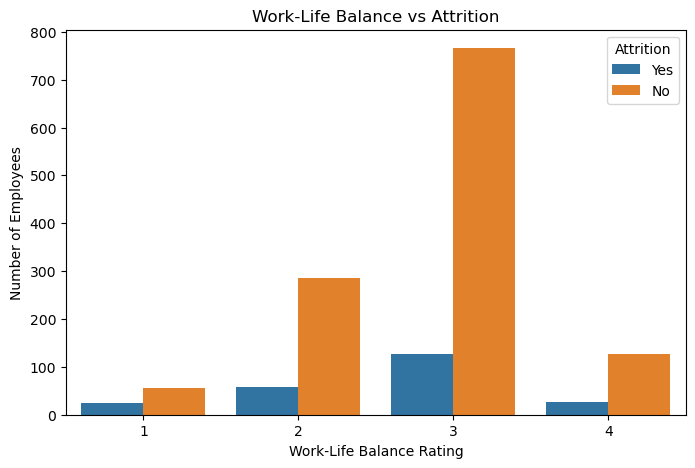

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.savefig("charts/chart4_worklife_attrition.png")

plt.show()

### Observation

Most employees have a Work-Life Balance rating of 3. Employees with lower work-life balance ratings (1 and 2) show a relatively higher proportion of attrition compared to employees with higher ratings.

### Business Insight

Improving work-life balance through flexible work policies, manageable workloads, and employee wellness initiatives may help reduce employee attrition.

## Attrition vs Years at Company

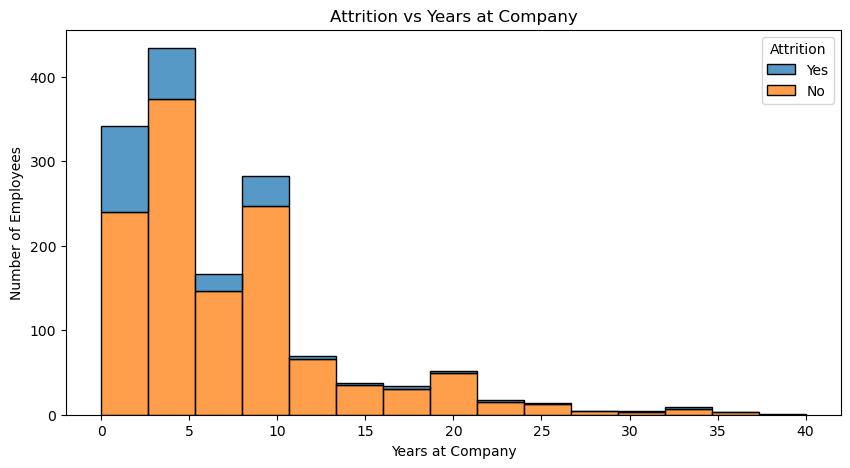

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=15
)

plt.title("Attrition vs Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")

plt.savefig("charts/chart5_years_at_company.png")

plt.show()

### Observation

Most employees who leave the company do so within the first 10 years of employment. Attrition decreases significantly as employee tenure increases, indicating that long-term employees are more likely to remain with the company.

### Business Insight

HR should focus on retaining employees during their early years by providing proper onboarding, career development opportunities, mentorship, and regular performance feedback.

## Business Insights from Exploratory Data Analysis

1. Research & Development has the highest number of employee exits because it has the largest workforce.

2. Sales Representatives have the highest attrition rate (39.76%), making them the highest-risk job role.

3. Employees with lower monthly income are more likely to leave the company.

4. Employees with poor work-life balance show relatively higher attrition.

5. Most employee resignations occur within the first 10 years of joining the company, highlighting the importance of early employee engagement and retention strategies.

# Task 4: Model Building & Comparison

In this task, the prepared dataset is divided into training and testing sets. Three machine learning classification models are trained and compared to predict whether an employee is likely to leave the company. Since the dataset is imbalanced, the `class_weight='balanced'` parameter is used where applicable to improve the model's performance on the minority class.

## Separating Features and Target Variable

The independent variables (features) are stored in **X**, while the target variable (**Attrition**) is stored in **y**.

In [34]:
X = df_clean.drop("Attrition", axis=1)

y = df_clean["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


## Splitting the Dataset

The dataset is divided into **80% training data** and **20% testing data**. The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (1176, 44)
Testing Data : (294, 44)


## Feature Scaling

The numerical features are standardized using **StandardScaler**. Feature scaling improves the performance of distance-based and linear models such as Logistic Regression.

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed Successfully.")

Scaling Completed Successfully.


## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for **classification** problems. It predicts the probability of an employee leaving the company (Attrition = Yes) or staying (Attrition = No).

Since the dataset is imbalanced, the `class_weight='balanced'` parameter is used to give equal importance to both classes.

In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [38]:
y_pred_lr[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is capable of capturing complex relationships within the data.

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [40]:
y_pred_rf[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Gradient Boosting Classifier

Gradient Boosting builds decision trees sequentially, where each new tree tries to correct the errors made by the previous trees. It often achieves high predictive performance on structured datasets.

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [42]:
y_pred_gb[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Task 5: Model Evaluation

The performance of all three machine learning models is evaluated using multiple classification metrics, including Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix. These metrics help identify the model that performs best in predicting employee attrition.

## Import Evaluation Metrics

In [43]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Logistic Regression Evaluation

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1 Score : 0.44274809160305345
ROC-AUC  : 0.6971746059092083

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



## Random Forest Evaluation

In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8367346938775511
Precision: 0.4444444444444444
Recall   : 0.0851063829787234
F1 Score : 0.14285714285714285
ROC-AUC  : 0.5324317339994831

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



## Gradient Boosting Evaluation

In [46]:
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_gb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_gb))

Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125
ROC-AUC  : 0.5922129382375743

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



## Model Comparison

The table below compares the performance of all three machine learning models using different evaluation metrics.

In [47]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_gb)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752,0.345,0.617,0.443,0.697
1,Random Forest,0.837,0.444,0.085,0.143,0.532
2,Gradient Boosting,0.850,0.588,0.213,0.312,0.592


### Observation

The three machine learning models showed different strengths and weaknesses.

- Gradient Boosting achieved the highest overall accuracy (85.03%) and precision (58.82%).
- Logistic Regression achieved the highest recall (61.70%) and F1-score (44.27%), making it the most effective model for identifying employees who are likely to leave.
- Random Forest achieved good accuracy but struggled to identify employees who left the company, resulting in a very low recall (8.51%).

### Business Insight

In employee attrition prediction, correctly identifying employees who are likely to leave is more important than simply achieving high accuracy. Missing employees who may resign can prevent HR from taking timely retention actions. Therefore, Logistic Regression provides the most balanced performance for this business problem.

## Confusion Matrix

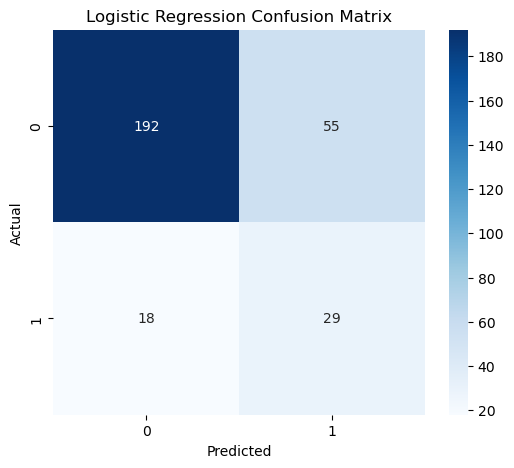

In [48]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/chart6_lr_confusion_matrix.png")

plt.show()

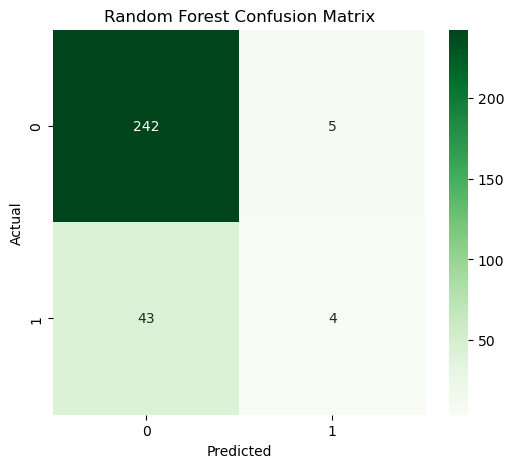

In [49]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/chart7_rf_confusion_matrix.png")

plt.show()

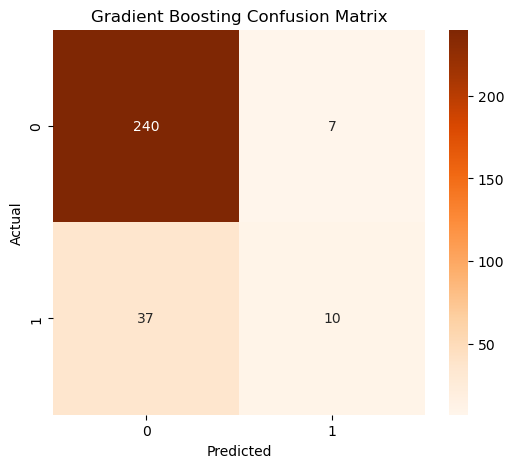

In [50]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/chart8_gb_confusion_matrix.png")

plt.show()

## ROC Curve Comparison

The ROC (Receiver Operating Characteristic) Curve compares the performance of all three classification models across different decision thresholds. A model with a curve closer to the top-left corner generally performs better at distinguishing between employees who are likely to leave and those who are likely to stay.

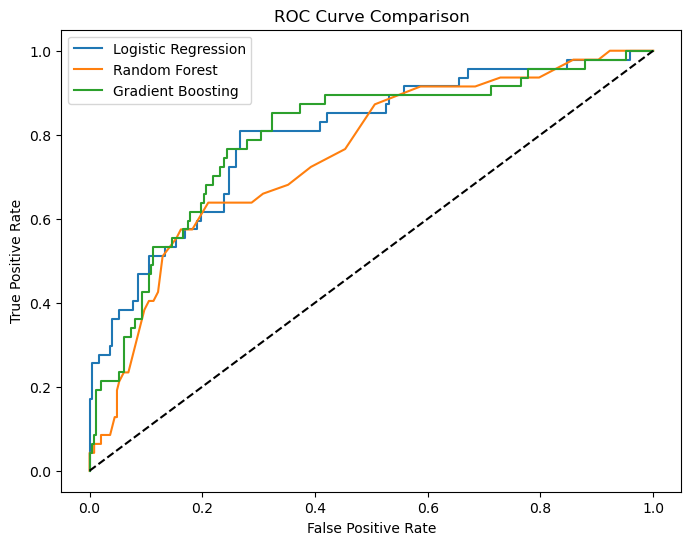

In [51]:
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

gb_prob = gb_model.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")

plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("charts/chart9_roc_curve.png")

plt.show()

### Observation

The ROC Curve compares the classification performance of all three models across different thresholds. Logistic Regression demonstrates better balance in identifying employees who are likely to leave, while Gradient Boosting shows strong overall performance but lower recall. Overall, Logistic Regression provides more practical value for employee attrition prediction.

### Business Insight

The ROC Curve confirms that model selection should not be based only on accuracy. For employee attrition prediction, the ability to correctly identify employees at risk of leaving is more valuable. Therefore, Logistic Regression is the most suitable model for supporting HR retention strategies.

## Best Performing Model

Although Gradient Boosting achieved the highest overall accuracy (85.03%), Logistic Regression was selected as the best model because it achieved the highest Recall (61.70%) and F1-Score (44.27%).

In employee attrition prediction, identifying employees who are likely to leave is more important than simply achieving high accuracy. A higher recall ensures that fewer employees at risk of leaving are missed, allowing the HR department to take timely retention actions.

## Top 10 Most Important Features

Since Logistic Regression was selected as the best-performing model, the importance of each feature is determined using the absolute value of its coefficients.

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lr_model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


## Top 10 Feature Importance Visualization

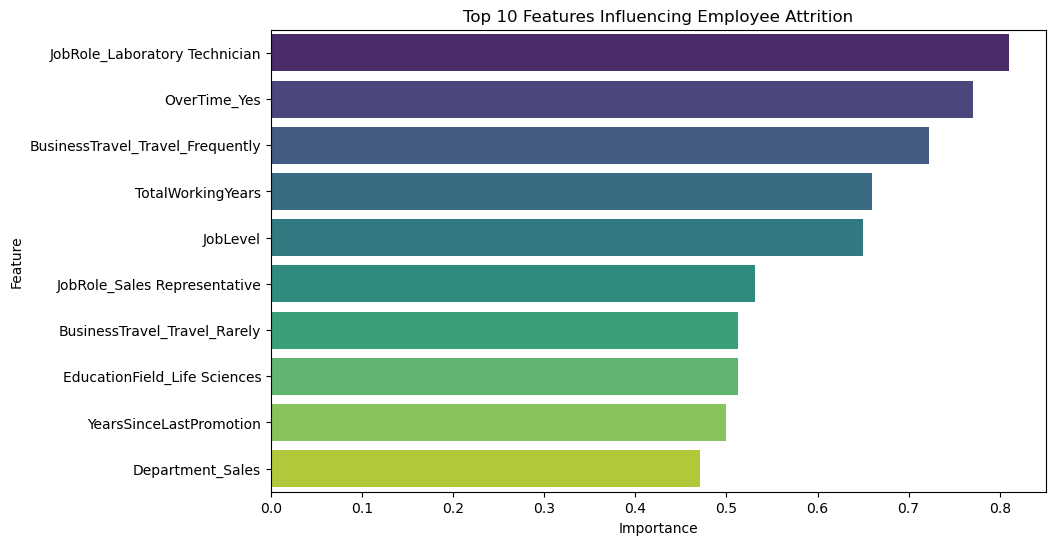

In [53]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Features Influencing Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("charts/chart10_feature_importance.png")

plt.show()

### Top 10 Factors Driving Employee Attrition

1. JobRole_Laboratory Technician
2. OverTime_Yes
3. BusinessTravel_Travel_Frequently
4. TotalWorkingYears
5. JobLevel
6. JobRole_Sales Representative
7. BusinessTravel_Travel_Rarely
8. EducationField_Life Sciences
9. YearsSinceLastPromotion
10. Department_Sales

### Observation

The Logistic Regression model identified several important factors influencing employee attrition. The most influential feature is JobRole_Laboratory Technician, followed by OverTime_Yes and BusinessTravel_Travel_Frequently. Other significant factors include Total Working Years, Job Level, Sales Representative, Years Since Last Promotion, and Department_Sales.

### Business Insight

Employee attrition is influenced by multiple workplace factors rather than a single reason. Employees working overtime, travelling frequently, and working in certain job roles are at higher risk of leaving. HR should focus on reducing excessive overtime, improving work-life balance, providing career growth opportunities, and implementing targeted retention programs for high-risk employees.

# Task 6: Visualization Summary

The visualizations created during this project provide meaningful insights into employee attrition patterns. They highlight differences in attrition across departments and job roles, the relationship between salary and employee turnover, the performance of the classification models, and the most influential factors contributing to employee attrition. These visualizations help transform machine learning results into actionable business insights for HR decision-making.

# Task 7: HR Insights & Business Recommendations

## 1. Which three factors most strongly predict employee attrition?

Based on the Logistic Regression model, the three strongest predictors of employee attrition are:

1. Job Role – Laboratory Technician
2. Overtime
3. Frequent Business Travel

These factors had the highest influence on predicting whether an employee is likely to leave the company.

## 2. Which department or job role should HR prioritize?

The analysis shows that Sales Representatives have the highest attrition rate (39.76%). Laboratory Technicians also have a high risk of leaving according to the machine learning model. Therefore, HR should prioritize these job roles for employee retention initiatives, regular feedback sessions, career development opportunities, and workload management.

## 3. Does salary alone explain employee attrition?

No. Although employees with lower monthly income tend to leave more frequently, salary is not the only factor. Overtime, business travel, job role, career growth, and work-life balance also play significant roles in influencing employee attrition.

## 4. HR Recommendations

1. Reduce excessive overtime and improve work-life balance through flexible work policies and employee wellness programs.

2. Focus on high-risk job roles such as Sales Representatives and Laboratory Technicians by providing career development opportunities, recognition programs, and regular employee engagement activities.

## 5. Model Limitation

This model is trained using historical employee data from a single dataset and may not generalize to every organization. Employee attrition is influenced by many external factors such as organizational culture, personal circumstances, and economic conditions, which are not fully captured in the dataset. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.

## Conclusion

In this project, employee attrition was analyzed using exploratory data analysis and machine learning techniques.

Three classification models were compared, and Logistic Regression was selected as the most suitable model because it provided the best balance for identifying employees who are likely to leave.

The project demonstrates how machine learning can help HR teams identify high-risk employees and support data-driven retention strategies.